In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/heart.csv")
df.shape

(918, 12)

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for col in ["RestingBP", "Cholesterol"]:
    X_train[col] = X_train[col].replace(0, np.nan)
    X_test[col] = X_test[col].replace(0, np.nan)

print(X_train.shape, X_test.shape)

(734, 11) (184, 11)


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

columnas_numericas = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
columnas_categoricas = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

transformador_numerico = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", MinMaxScaler())
])

transformador_categorico = Pipeline(steps=[
    ("codificar", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer(transformers=[
    ("num", transformador_numerico, columnas_numericas),
    ("cat", transformador_categorico, columnas_categoricas)
])

print("Preprocesador listo")

Preprocesador listo


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline_final = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("clf", LogisticRegression(max_iter=1000))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100]
}

grid_final = GridSearchCV(pipeline_final, param_grid, cv=5, scoring="roc_auc")
grid_final.fit(X_train, y_train)

print("Mejor C:", grid_final.best_params_)
print("Mejor AUC en validación cruzada:", grid_final.best_score_)

Mejor C: {'clf__C': 1}
Mejor AUC en validación cruzada: 0.9233665078088793


In [5]:
from sklearn.metrics import roc_auc_score, accuracy_score

y_proba = grid_final.predict_proba(X_test)[:, 1]
y_pred = grid_final.predict(X_test)

auc_test = roc_auc_score(y_test, y_proba)
acc_test = accuracy_score(y_test, y_pred)

print("AUC en test:", auc_test)
print("Accuracy en test:", acc_test)

AUC en test: 0.9311809685641461
Accuracy en test: 0.8641304347826086


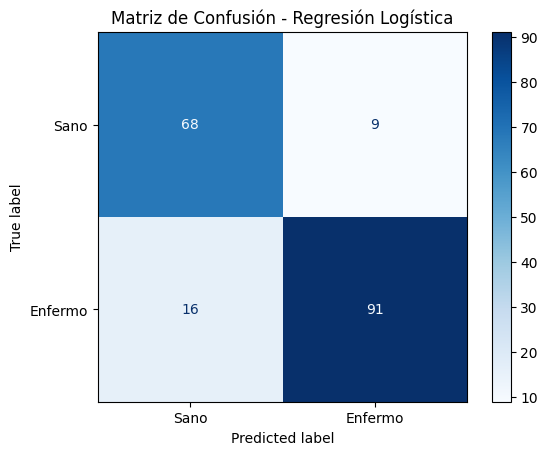

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sano", "Enfermo"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

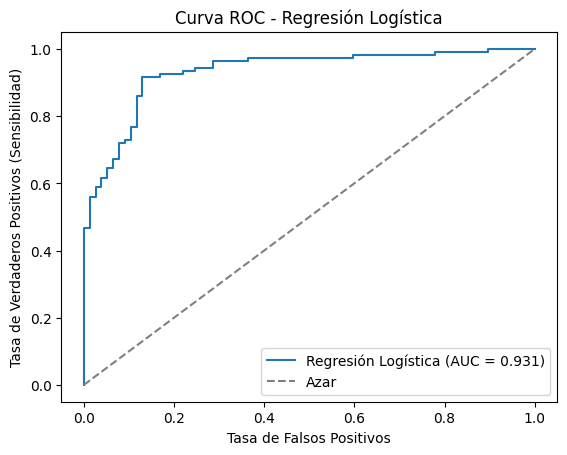

In [7]:
from sklearn.metrics import roc_curve

fpr, tpr, umbrales = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {auc_test:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.show()

In [9]:
mkdir -p app docker k8s tests .github/workflows

In [11]:
import joblib

joblib.dump(grid_final.best_estimator_, "../app/model.joblib")

['../app/model.joblib']

In [12]:
%pip install fastapi uvicorn pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [fastapi]m1/3 [starlette]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
